# 05 · Tree models
Random forest and gradient boosting, tuned on 2012–2018 (`src/tune_models.py`), compared with the logistic regression.

**Result:** tuned tree models are close to but worse than logistic regression on both periods, and blending them in doesn't help: their predictions correlate 0.94–0.97 with the logistic regression's, so they add noise, not new information. The best boosting setup is its simplest one (3-leaf trees), which says the signal here is mostly linear.

In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
import json, pandas as pd, matplotlib.pyplot as plt
from src.config import ROOT, MODELS_DIR
res = pd.DataFrame(json.loads((ROOT / 'reports' / 'results.json').read_text())).rename(columns={'index': 'model'})
res.pivot(index='model', columns='period', values='log_loss').sort_values('holdout 2019-25').round(4)

period,holdout 2019-25,tuning 2012-18
model,,
vegas,0.6083,0.6101
logistic,0.6285,0.6156
random_forest,0.6294,0.6216
gradient_boosting,0.6295,0.6222
elo,0.6367,0.6248


## Chosen settings (tuning seasons only)

In [2]:
json.loads((MODELS_DIR / 'model_params.json').read_text())

{'gbm': {'features': 'all_features',
  'log_loss': 0.6220592699943303,
  'params': {'learning_rate': 0.03,
   'max_iter': 150,
   'max_leaf_nodes': 3,
   'min_samples_leaf': 80}},
 'rf': {'features': 'all_features',
  'log_loss': 0.6213615755811442,
  'params': {'min_samples_leaf': 50, 'max_features': 0.2}}}

## Where do the models disagree?
Out-of-sample predictions for the holdout seasons.

                   logistic  random_forest  gradient_boosting
logistic              1.000          0.959               0.96
random_forest         0.959          1.000               0.98
gradient_boosting     0.960          0.980               1.00


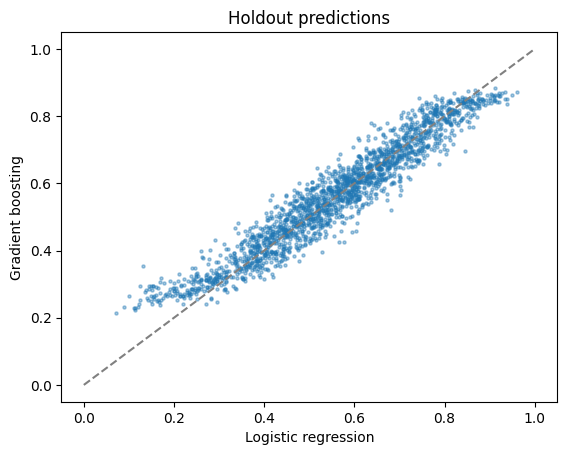

In [3]:
from src.evaluate import load_played_games, walk_forward
from src.train import MODELS
games = load_played_games()
H = range(2019, 2026)
p = {n: walk_forward(games, *MODELS[n], H).set_index('game_id').p_home for n in MODELS}
p = pd.DataFrame(p)
print(p.corr().round(3))
plt.scatter(p.logistic, p.gradient_boosting, s=5, alpha=0.4)
plt.plot([0, 1], [0, 1], ls='--', c='gray'); plt.xlabel('Logistic regression'); plt.ylabel('Gradient boosting')
plt.title('Holdout predictions'); plt.show()

## What the gradient boosting model leans on
Permutation importance on the holdout: how much log loss worsens when a feature is shuffled.

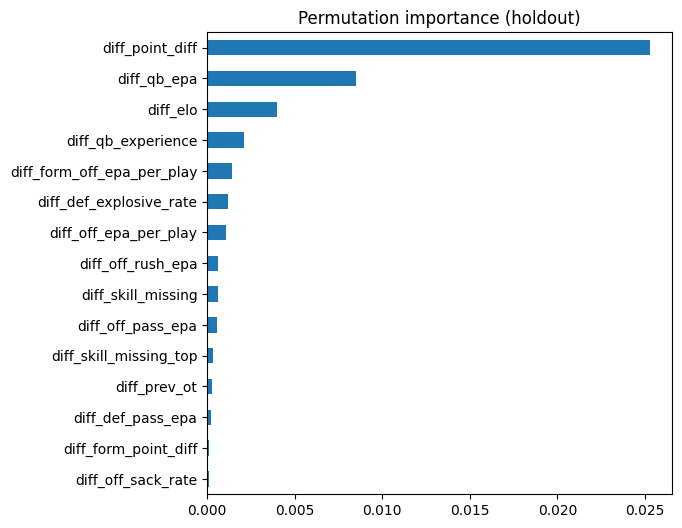

In [4]:
from sklearn.inspection import permutation_importance
from src.train import MODELS
factory, cols = MODELS['gradient_boosting']
train, test = games[games.season < 2019], games[games.season >= 2019]
m = factory().fit(train[cols], train.home_win)
imp = permutation_importance(m, test[cols], test.home_win, scoring='neg_log_loss', n_repeats=5, random_state=0)
pd.Series(imp.importances_mean, index=cols).sort_values().tail(15).plot.barh(figsize=(6, 6), title='Permutation importance (holdout)'); plt.show()